# Data Exploration


c:\Users\user\Desktop\Bayesian-Hyperparameter-Tuning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


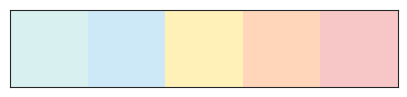

In [5]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from matplotlib.ticker import FuncFormatter

# Modelling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score

import lightgbm as lgb

# Hyperparameter tuning
from hyperopt import fmin, rand, tpe, space_eval, STATUS_OK, Trials, hp
from hyperopt.pyll.stochastic import sample
from bayes_opt import BayesianOptimization
import optuna

sns.set_style("white")

### Define the colour scheme
c1 = "#D9F0F0"
c2 = "#CDE8F6"
c3 = "#FFF1B8"
c4 = "#FFD6BA"
c5 = "#F7C6C7"

custom_palette = [c1, c2, c3, c4, c5]
sns.palplot(sns.color_palette(custom_palette))

# User defined function
def summary(df):
    summ = pd.DataFrame(df.dtypes, columns=['data type'])
    summ['#total'] = df.shape[0]
    summ['#missing'] = df.isnull().sum().values 
    summ['%missing'] = df.isnull().sum().values / len(df)* 100
    summ['#unique'] = df.nunique().values
    summ['#duplicates'] = summ['#total'] - summ['#unique']
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['min'] = desc['min'].values
    summ['max'] = desc['max'].values
    return summ

In [ ]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

from src.data import load_data, report

data_path = Path.cwd().parent / "data" / "processed" / "train.csv"

df = load_data(path=data_path)
                    
print(df.shape)
print(report(df))
print(df.head())

(200000, 202)
{'shape': (200000, 202), 'missing': 0, 'duplicates': 0, 'positive_rate': 0.10049}
   ID_code  target    var_0   var_1    var_2   var_3    var_4   var_5   var_6  \
0  train_0       0   8.9255 -6.7863  11.9081  5.0930  11.4607 -9.2834  5.1187   
1  train_1       0  11.5006 -4.1473  13.8588  5.3890  12.3622  7.0433  5.6208   
2  train_2       0   8.6093 -2.7457  12.0805  7.8928  10.5825 -9.0837  6.9427   
3  train_3       0  11.0604 -2.1518   8.9522  7.1957  12.5846 -1.8361  5.8428   
4  train_4       0   9.8369 -1.4834  12.8746  6.6375  12.2772  2.4486  5.9405   

     var_7  ...  var_190  var_191  var_192  var_193  var_194  var_195  \
0  18.6266  ...   4.4354   3.9642   3.1364   1.6910  18.5227  -2.3978   
1  16.5338  ...   7.6421   7.7214   2.5837  10.9516  15.4305   2.0339   
2  14.6155  ...   2.9057   9.7905   1.6704   1.6858  21.6042   3.1417   
3  14.9250  ...   4.4666   4.7433   0.7178   1.4214  23.0347  -1.2706   
4  19.2514  ...  -1.4905   9.5214  -0.1508   9.1942 

In [3]:
summary(df.iloc[:, :13]).style.background_gradient(cmap='Blues')

,data type,#total,#missing,%missing,#unique,#duplicates,min,max
ID_code,str,200000,0,0.000000,200000,0,nan,nan
target,int64,200000,0,0.000000,2,199998,0.000000,1.000000
var_0,float64,200000,0,0.000000,94672,105328,0.408400,20.315000
var_1,float64,200000,0,0.000000,108932,91068,-15.043400,10.376800
var_2,float64,200000,0,0.000000,86555,113445,2.117100,19.353000
var_3,float64,200000,0,0.000000,74597,125403,-0.040200,13.188300
var_4,float64,200000,0,0.000000,63515,136485,5.074800,16.671400
var_5,float64,200000,0,0.000000,141029,58971,-32.562600,17.251600
var_6,float64,200000,0,0.000000,38599,161401,2.347300,8.447700
var_7,float64,200000,0,0.000000,103063,96937,5.349700,27.691800


In [4]:
X = df.drop(['ID_code', 'target'], axis = 1).copy()
y = df[['target']]

In [6]:
n_bads = df[df['target']==1].shape[0] 
print("Number of Bads:\t",n_bads)

Number of Bads:	 20098


In [7]:
#Training & Testing Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

In [9]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160000, 200)
(40000, 200)
(160000, 1)
(40000, 1)


## 3. Creating a Balanced Sample

The dataset is highly imbalanced, with significantly more `good` observations (`target = 0`) than `bad` observations (`target = 1`). To make experimentation faster, we undersample the good population.

The following steps:

1. Selects a random sample of good observations equal to the number of bad observations.
2. Combines the sampled good observations with all bad observations.
3. Separates the features from the target variable.
4. Splits the data into training and testing sets while preserving class proportions.
5. Creates a LightGBM training dataset.

This balanced sample is intended for demonstration and computational efficiency. It should not replace the original population when reporting final model performance.

In [15]:
df_small_good = df[df["target"] == 0].sample(
    n=n_bads,
    random_state=888
)

df_small_bad = df[df["target"] == 1]

df_small = pd.concat(
    [df_small_good, df_small_bad],
    ignore_index=True
).sample(frac=1, random_state=888)

print(df_small["target"].value_counts())

X = df_small.drop(columns=["ID_code", "target"])
y = df_small["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=888
)

train_data = lgb.Dataset(X_train, label=y_train)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

target
0    20098
1    20098
Name: count, dtype: int64
X_train shape: (32156, 200)
X_test shape: (8040, 200)
y_train shape: (32156,)
y_test shape: (8040,)


# 4. Hyperparameter Tuning

Hyperparameter tuning is the process of systematically searching for the configuration settings that produce the best-performing machine-learning model. These settings are defined before training and are not learned directly from the data.

The objective can be represented as:

$$
\theta^* = \arg\min_{\theta \in \Theta} f(\theta)
$$

where:

- $\theta$ represents a set of hyperparameters.
- $\Theta$ represents the hyperparameter search space.
- $f(\theta)$ represents the objective function.
- $\theta^*$ represents the optimal hyperparameter configuration.

In this project, model performance is evaluated using the validation ROC-AUC score. The goal is to identify hyperparameters that maximize this score.

## 4.1 Random Search

Random search evaluates randomly selected combinations of hyperparameters from the defined search space.

Unlike grid search, which evaluates every predefined combination, random search samples a fixed number of configurations. This can be more efficient when only a few hyperparameters have a strong influence on model performance.

### Advantages

- Simple to implement.
- Easy to parallelize.
- Effective for large search spaces.
- Does not require a model of the objective function.

### Limitations

- Previous evaluations are not used to guide future trials.
- Computational resources may be spent on poor configurations.
- Results can vary depending on the random seed.

## 4.2 Bayesian Optimization

Bayesian optimization uses the results of previous evaluations to select promising hyperparameter configurations. Instead of searching randomly, it builds a probabilistic approximation of the objective function.

The process consists of:

1. Evaluating an initial set of hyperparameter configurations.
2. Fitting a surrogate model to the observed results.
3. Using an acquisition function to select the next configuration.
4. Evaluating the new configuration.
5. Updating the surrogate model.
6. Repeating the process until the evaluation budget is exhausted.

Bayesian optimization is especially useful when model training is expensive because it attempts to minimize the number of unnecessary evaluations.

## 4.3 Surrogate Model

The surrogate model estimates the relationship between the hyperparameters and the validation score:

$$
f(\theta) \approx \hat{f}(\theta)
$$

A common choice is a Gaussian process, which predicts both:

- The expected objective value.
- The uncertainty associated with that prediction.

The surrogate model is updated after every trial, allowing the optimization process to focus on promising regions of the search space while still exploring uncertain regions.

## 4.4 Acquisition Function

The acquisition function determines which hyperparameter configuration should be evaluated next. It balances:

- **Exploitation:** selecting configurations predicted to perform well.
- **Exploration:** selecting configurations where the surrogate model is uncertain.

One commonly used acquisition function is Expected Improvement:

$$
EI(\theta) =
\mathbb{E}
\left[
\max\left(f(\theta) - f(\theta^+), 0\right)
\right]
$$

where $\theta^+$ is the best configuration observed so far.

For a minimization problem, the corresponding form is:

$$
EI(\theta) =
\mathbb{E}
\left[
\max\left(f(\theta^+) - f(\theta), 0\right)
\right]
$$

The next trial is selected by optimizing the acquisition function:

$$
\theta_{next} = \arg\max_{\theta \in \Theta} EI(\theta)
$$

## 4.5 Comparison of Search Strategies

| Method | Search strategy | Uses previous results | Main advantage |
|---|---|---:|---|
| Random search | Randomly samples configurations | No | Simple and easy to parallelize |
| Bayesian optimization | Selects configurations using a surrogate model | Yes | Efficient for expensive model evaluations |

Random search provides a useful baseline for comparison. Bayesian optimization is then used to determine whether an informed search strategy can achieve a better validation score with fewer evaluations.

> The balanced dataset used in this project is intended for computationally efficient experimentation and visual demonstration. Final model performance should be evaluated using the original class distribution.